# Đánh giá Định lượng Mô hình Đã Huấn luyện (Quantitative Evaluation on Test Set)

Thực hiện **Giai đoạn 4: Đánh giá & Triển khai** bằng cách kiểm tra độ chính xác của mô hình **Llama-3.1-8B (1-LoRA) + RAG** trên tập kiểm thử độc lập `data/processed/test.csv`.

**Các chỉ số đánh giá học thuật bao gồm:**
1. **QWK (Quadratic Weighted Kappa)**: Chỉ số tiêu chuẩn đánh giá mức độ tương quan và đồng thuận giữa AI và giám khảo con người (Human-AI Agreement).
2. **MAE (Mean Absolute Error)**: Sai số tuyệt đối trung bình (đo độ lệch điểm trung bình giữa AI và con người).

In [1]:
import os
import sys
import json
import re
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, confusion_matrix
from dotenv import load_dotenv

# Nạp cấu hình môi trường
load_dotenv(os.path.abspath("../.env"))

# Thêm src vào path
sys.path.append(os.path.abspath("../src"))
from rag import rag_utils

t:\5 - Summer 2026\AES_LLM\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Tải tập kiểm thử độc lập và cơ sở dữ liệu Vector RAG

In [2]:
df_test = pd.read_csv("../data/processed/test.csv")
print(f"Đã nạp {len(df_test)} mẫu từ tập Test.")

VECTOR_DB_DIR = "../data/processed/chroma_db"
vectordb = rag_utils.load_vector_db(VECTOR_DB_DIR)
print("✔ Đã nạp thành công ChromaDB.")

Đã nạp 492 mẫu từ tập Test.


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 5746.13it/s]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
t:\5 - Summer 2026\AES_LLM\src\rag\rag_utils.py:28: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectordb = Chroma(


✔ Đã nạp thành công ChromaDB.


## 2. Thiết lập hàm gọi Inference từ Ollama Local Server

Mô hình `llama3-1-aes-8b` cần được khởi động sẵn thông qua Ollama (`ollama run llama3-1-aes-8b`).

In [3]:
from rag.rag_utils import IELTS_EVAL_PROMPT_TEMPLATE
OLLAMA_API_URL = "http://localhost:11434/api/generate"
OLLAMA_MODEL_NAME = "llama3-1-aes-8b"
print("✔ Đã import IELTS_EVAL_PROMPT_TEMPLATE tập trung!")

✔ Đã import IELTS_EVAL_PROMPT_TEMPLATE tập trung!


In [4]:
def extract_clean_json(text):
    match = re.search(r'\{.*\}', text, re.DOTALL)
    return match.group(0) if match else text

def evaluate_essay_ollama(essay_prompt, essay_text):
    # 1. Truy xuất RAG chuẩn
    retrieved_docs = rag_utils.retrieve_examples(vectordb, essay_text, k=2)
    context_str = rag_utils.format_rag_context(retrieved_docs)
    
    # 2. Tạo prompt
    final_prompt = rag_utils.format_evaluation_prompt(
        prompt_template=IELTS_EVAL_PROMPT_TEMPLATE,
        context=context_str,
        essay_prompt=essay_prompt,
        essay_text=essay_text
    )
    
    # 3. Request sang Ollama với định dạng JSON và timeout=120s
    payload = {
        "model": OLLAMA_MODEL_NAME,
        "prompt": final_prompt,
        "format": "json",
        "stream": False,
        "options": {
            "temperature": 0.1
        }
    }
    try:
        res = requests.post(OLLAMA_API_URL, json=payload, timeout=300.0)
        if res.status_code == 200:
            raw_response = res.json().get("response", "").strip()
            json_str = extract_clean_json(raw_response)
            return json.loads(json_str)
    except Exception as e:
        print(f"Lỗi kết nối tới Ollama: {e}")
    return None

## 3. Thực thi đánh giá hàng loạt trên tập mẫu thử nghiệm

Để tiết kiệm thời gian chạy thử nghiệm cục bộ, Lấy mẫu ngẫu nhiên **30 bài viết** từ tập Test độc lập để đối chiếu.

In [5]:
df_eval_sample = df_test.sample(n=30, random_state=42).reset_index(drop=True)

predicted_tr, predicted_cc, predicted_lr, predicted_gra = [], [], [], []
ground_truth_tr, ground_truth_cc, ground_truth_lr, ground_truth_gra = [], [], [], []

print("Bắt đầu đánh giá hàng loạt trên 30 mẫu thử nghiệm...")
for idx, row in df_eval_sample.iterrows():
    print(f"⏳ Đang chấm bài {idx+1}/30...")
    res_dict = evaluate_essay_ollama(row['prompt'], row['essay'])
    
    if res_dict:
        try:
            # Trích xuất điểm AI
            ai_tr = float(res_dict['Task_Response']['Band'])
            ai_cc = float(res_dict['Coherence_and_Cohesion']['Band'])
            ai_lr = float(res_dict['Lexical_Resource']['Band'])
            ai_gra = float(res_dict['Grammatical_Range_and_Accuracy']['Band'])
            
            predicted_tr.append(ai_tr)
            predicted_cc.append(ai_cc)
            predicted_lr.append(ai_lr)
            predicted_gra.append(ai_gra)
            
            # Trích xuất điểm chuẩn (Ground Truth)
            ground_truth_tr.append(float(row['TR_Band']))
            ground_truth_cc.append(float(row['CC_Band']))
            ground_truth_lr.append(float(row['LR_Band']))
            ground_truth_gra.append(float(row['GRA_Band']))
        except Exception as parse_ex:
            print(f"Lỗi phân tích cú pháp bài {idx+1}: {parse_ex}")
            
print("✔ Đã hoàn thành chấm điểm mẫu!")

Bắt đầu đánh giá hàng loạt trên 30 mẫu thử nghiệm...
⏳ Đang chấm bài 1/30...
⏳ Đang chấm bài 2/30...
⏳ Đang chấm bài 3/30...
⏳ Đang chấm bài 4/30...
⏳ Đang chấm bài 5/30...
⏳ Đang chấm bài 6/30...
⏳ Đang chấm bài 7/30...
⏳ Đang chấm bài 8/30...
⏳ Đang chấm bài 9/30...
⏳ Đang chấm bài 10/30...
⏳ Đang chấm bài 11/30...
⏳ Đang chấm bài 12/30...
⏳ Đang chấm bài 13/30...
⏳ Đang chấm bài 14/30...
⏳ Đang chấm bài 15/30...
⏳ Đang chấm bài 16/30...
⏳ Đang chấm bài 17/30...
⏳ Đang chấm bài 18/30...
⏳ Đang chấm bài 19/30...
⏳ Đang chấm bài 20/30...
⏳ Đang chấm bài 21/30...
⏳ Đang chấm bài 22/30...
⏳ Đang chấm bài 23/30...
⏳ Đang chấm bài 24/30...
⏳ Đang chấm bài 25/30...
⏳ Đang chấm bài 26/30...
⏳ Đang chấm bài 27/30...
⏳ Đang chấm bài 28/30...
⏳ Đang chấm bài 29/30...
⏳ Đang chấm bài 30/30...
✔ Đã hoàn thành chấm điểm mẫu!


In [6]:
import pandas as pd

# 1. In ra danh sách điểm số thô để đối chiếu từng bài
print("=== DANH SÁCH ĐIỂM SỐ CHI TIẾT (TASK RESPONSE) ===")
print(f"Ground Truth (Con người) ({len(ground_truth_tr)} bài):")
print(ground_truth_tr)
print(f"\nPredicted (Mô hình AI) ({len(predicted_tr)} bài):")
print(predicted_tr)

# 2. Tạo DataFrame phân tích tần suất xuất hiện của từng điểm số
df_dist = pd.DataFrame({
    'Ground Truth': ground_truth_tr,
    'Predicted': predicted_tr
})

print("\n" + "="*50)
print("=== BẢNG TẦN SUẤT XUẤT HIỆN ĐIỂM SỐ ===")
dist_compare = pd.DataFrame({
    'Giám khảo (Human)': df_dist['Ground Truth'].value_counts().sort_index(),
    'Mô hình AI (LLM)': df_dist['Predicted'].value_counts().sort_index()
}).fillna(0).astype(int)

print(dist_compare)

# 3. Tính độ phân sai (Standard Deviation) để xem mức độ phân hóa điểm
print("\n" + "="*50)
print(f"Độ lệch chuẩn của Giám khảo: {df_dist['Ground Truth'].std():.4f} (Càng cao càng phân hóa tốt)")
print(f"Độ lệch chuẩn của Mô hình AI: {df_dist['Predicted'].std():.4f} (Nếu ~0 tức là AI đang chấm phẳng)")


=== DANH SÁCH ĐIỂM SỐ CHI TIẾT (TASK RESPONSE) ===
Ground Truth (Con người) (30 bài):
[7.5, 7.0, 5.0, 5.0, 4.0, 4.0, 6.0, 5.0, 7.5, 6.0, 6.0, 7.0, 5.0, 7.0, 7.0, 4.0, 5.0, 6.5, 3.0, 5.0, 7.0, 6.0, 7.0, 6.5, 8.0, 4.0, 6.0, 7.0, 5.0, 4.0]

Predicted (Mô hình AI) (30 bài):
[5.5, 6.5, 4.0, 3.0, 3.5, 3.0, 6.0, 4.0, 6.0, 4.0, 4.5, 4.5, 6.5, 3.5, 4.0, 4.0, 3.5, 4.0, 4.5, 4.0, 5.0, 5.0, 4.0, 3.5, 5.0, 3.5, 5.5, 4.0, 5.0, 5.0]

=== BẢNG TẦN SUẤT XUẤT HIỆN ĐIỂM SỐ ===
     Giám khảo (Human)  Mô hình AI (LLM)
3.0                  1                 2
3.5                  0                 5
4.0                  5                 9
4.5                  0                 3
5.0                  7                 5
5.5                  0                 2
6.0                  5                 2
6.5                  2                 2
7.0                  7                 0
7.5                  2                 0
8.0                  1                 0

Độ lệch chuẩn của Giám khảo: 1.3179 (Càng ca

## 4. Tính toán các chỉ số học thuật QWK và MAE

**QWK (Quadratic Weighted Kappa)**  
Là chỉ số đo **độ giống nhau** giữa điểm số mà AI chấm và điểm số giám khảo con người chấm thật.  
- Giá trị = **1.0**: Hoàn hảo (AI chấm giống hệt).  
- Giá trị **lớn hơn 0.7**: Tốt, có thể dùng thực tế.  
- Giá trị **nhỏ hơn 0.5**: Chưa đạt yêu cầu.

**MAE (Mean Absolute Error)**  
Là độ lệch điểm **trung bình** giữa AI và điểm thật.  
- MAE = **0.3**: AI chỉ lệch trung bình 0.3 band điểm.  
- MAE **nhỏ hơn 0.5**: Được coi là rất tốt cho việc chấm IELTS.

In [7]:
metrics_results = []

criteria = [
    ("Task Response", ground_truth_tr, predicted_tr),
    ("Coherence & Cohesion", ground_truth_cc, predicted_cc),
    ("Lexical Resource", ground_truth_lr, predicted_lr),
    ("Grammatical Range & Accuracy", ground_truth_gra, predicted_gra)
]

# Tính điểm trung bình (Overall Band)
gt_overall = [(g_tr+g_cc+g_lr+g_gra)/4.0 for g_tr, g_cc, g_lr, g_gra in zip(ground_truth_tr, ground_truth_cc, ground_truth_lr, ground_truth_gra)]
pred_overall = [(p_tr+p_cc+p_lr+p_gra)/4.0 for p_tr, p_cc, p_lr, p_gra in zip(predicted_tr, predicted_cc, predicted_lr, predicted_gra)]

# Áp dụng làm tròn điểm IELTS
gt_overall_rounded = [round(v*2)/2 for v in gt_overall]
pred_overall_rounded = [round(v*2)/2 for v in pred_overall]

criteria.append(("Overall Band Score", gt_overall_rounded, pred_overall_rounded))

for crit_name, y_true, y_pred in criteria:
    # Nhân 2 lên để đưa về dạng số nguyên (integer) phục vụ QWK
    y_true_int = [int(v * 2) for v in y_true]
    y_pred_int = [int(v * 2) for v in y_pred]
    
    qwk = cohen_kappa_score(y_true_int, y_pred_int, weights='quadratic')
    mae = mean_absolute_error(y_true, y_pred)
    
    metrics_results.append({
        "Criterion": crit_name,
        "QWK (Cohen Kappa)": round(qwk, 4),
        "MAE (Mean Absolute Error)": round(mae, 4)
    })

df_metrics = pd.DataFrame(metrics_results)
print("=== BẢNG CHỈ SỐ NGHIỆM THU HỌC THUẬT ===")
print(df_metrics.to_string(index=False))

=== BẢNG CHỈ SỐ NGHIỆM THU HỌC THUẬT ===
                   Criterion  QWK (Cohen Kappa)  MAE (Mean Absolute Error)
               Task Response             0.1909                     1.5667
        Coherence & Cohesion             0.1751                     1.7500
            Lexical Resource             0.2216                     1.5500
Grammatical Range & Accuracy             0.1456                     1.7000
          Overall Band Score             0.1726                     1.6000


## 5. Vẽ ma trận nhầm lẫn (Confusion Matrix) cho điểm Overall Band

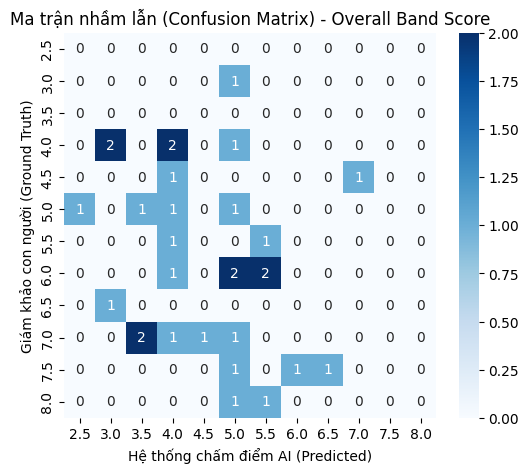

In [8]:
# 1. Lấy danh sách các nhãn điểm số duy nhất dưới dạng số thực và sắp xếp tăng dần
unique_labels_float = sorted(list(set(gt_overall_rounded + pred_overall_rounded)))

# 2. Chuyển đổi nhãn và dữ liệu về dạng chuỗi (string) để scikit-learn không nhận nhầm là biến liên tục (continuous)
unique_labels_str = [str(v) for v in unique_labels_float]
gt_overall_str = [str(v) for v in gt_overall_rounded]
pred_overall_str = [str(v) for v in pred_overall_rounded]

# 3. Tính toán ma trận nhầm lẫn dựa trên dữ liệu dạng chuỗi ký tự
cm = confusion_matrix(gt_overall_str, pred_overall_str, labels=unique_labels_str)

# 4. Vẽ biểu đồ Heatmap hiển thị ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=unique_labels_str, 
    yticklabels=unique_labels_str
)
plt.title("Ma trận nhầm lẫn (Confusion Matrix) - Overall Band Score")
plt.ylabel("Giám khảo con người (Ground Truth)")
plt.xlabel("Hệ thống chấm điểm AI (Predicted)")
plt.show()
